# Ames Housing - End-to-End Machine Learning Project

**Project Objective:** Building a regression model to predict the house sales price (`SalePrice`) based on dozens of property features. This project covers the full Data Science lifecycle: from data engineering (SQL database creation), data extraction, handling missing values (Imputation), and Feature Engineering, to training ML models.

**Data Source:** This project uses the *Ames Housing Dataset* (79 variables) from the official Kaggle competition. Kaggle provides pre-split datasets: `train.csv` (with target variable for training) and `test.csv` (without prices, for evaluation). During the EDA phase, we exclusively use the training set.

---


## Step 0: Environment Setup



In [1]:

!pip install xgboost

import os
import sqlite3
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


from sklearn.linear_model import ElasticNet
from xgboost import XGBRegressor

print("All libraries successfully imported! Environment is ready.")

All libraries successfully imported! Environment is ready.



## Step 1: Data Engineering & Business Logic
The raw data from Kaggle comes as a single, flat CSV file. In commercial projects, real estate data is never stored in one giant spreadsheet – it is usually scattered across relational databases managed by different departments. 

To simulate a relational database environment, I needed to split the 81-column flat file into three distinct tables. 

To be completely pragmatic: I didn't read all 81 column descriptions to find perfect logical breakpoints. Instead, knowing I needed 3 tables to effectively demonstrate SQL JOIN operations, I divided the columns into three roughly equal chunks using index ranges (1-29, 30-59, 60-80). 

After a quick visual check of the columns falling into each chunk, I assigned them domain-appropriate table names that fit the real estate context:
*   **`lot` table (Columns 1-29):** Starts with zoning and neighborhood, effectively covering the land and exterior.
*   **`interior` table (Columns 30-59):** Starts around basement features, covering the interior specs.
*   **`pricing` table (Columns 60-80):** Covers garages, outdoor amenities, and ends with the final `SalePrice`.

This is a practical shortcut to generate a working SQL architecture and simulate a multi-department enterprise database without over-engineering the initial setup.

In [87]:

df_raw = pd.read_csv('data/train.csv')


df_lot = df_raw.iloc[:, [0] + list(range(1, 30))]
df_interior = df_raw.iloc[:, [0] + list(range(30, 60))]
df_pricing =  df_raw.iloc[:, [0] + list(range(60, 81))]


conn = sqlite3.connect('housing.db')

df_lot.to_sql('lot', conn, index=False, if_exists='replace')
df_interior.to_sql('interior', conn, index=False, if_exists='replace')
df_pricing.to_sql('pricing', conn, index=False, if_exists='replace')

conn.close()

print(f"File size: {os.path.getsize('housing.db') / 1024:.2f} KB")

File size: 436.00 KB


### Step 2: Data Extraction (SQL)

Now that our relational database `housing.db` is up and running, we switch to the role of a Data Scientist. We use SQL queries directly in Python to extract the scattered information from the three tables and merge them back into a single, comprehensive dataset.
 
We use `LEFT JOIN` with the `lot` table as our base. This is an intentional defensive programming practice: it guarantees that **no properties (rows) are ever lost** during the merge. Even if a record happens to be missing or mismatched in the secondary tables (`interior` or `pricing`), our base properties remain intact, preventing unexpected data loss.

In [88]:

conn = sqlite3.connect('housing.db')

query = """
    SELECT *
    FROM lot l
    LEFT JOIN interior i ON l.Id = i.Id
    LEFT JOIN pricing p ON l.Id = p.Id
"""


df_housing = pd.read_sql(query, conn)
conn.close()

df_housing = df_housing.loc[:, ~df_housing.columns.duplicated()]

print(f"Dataset shape: {df_housing.shape[0]} rows and {df_housing.shape[1]} columns.")
df_housing.head(3)

Dataset shape: 1460 rows and 81 columns.


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,9,2008,WD,Normal,223500


## Step 3: Data Cleaning & EDA - Handling Missing Values
Machine Learning models require a complete matrix of features. Our first step is to audit the dataset for missing information (`NaN`) and decide on an imputation strategy. We will calculate both the absolute count and the percentage of missing data for each column.

In [89]:
missing_count = df_housing.isnull().sum()
missing_percent = (missing_count / len(df_housing)) * 100

df_missing = pd.DataFrame({
    'Missing_Count': missing_count, 
    'Missing_Percent': missing_percent
})


df_missing = df_missing[df_missing['Missing_Count'] > 0].sort_values(by='Missing_Percent', ascending=False)

print(f"Total columns with missing values: {df_missing.shape[0]}")
df_missing.head(15)

Total columns with missing values: 19


,Missing_Count,Missing_Percent
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


### Step 3a: The "NaN" Trap & Imputation Strategy
A critical business observation: in this dataset, a high percentage of missing values does not necessarily indicate bad data. According to the data dictionary, for structural features (like Pools, Fireplaces, or Garages), `NaN` simply means the property lacks that feature. 

Our imputation strategy:
*   **Structural Categories:** Replace `NaN` with `"None"` (e.g., no pool, no fireplace).
*   **Continuous Variables:** Replace `NaN` in `LotFrontage` with the median to avoid outlier skew.
*   **Numerical structural lack:** Replace `NaN` in `GarageYrBlt` with `0` (no garage = no year built).

In [90]:
cols_none = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'MasVnrType']

for col in cols_none:
    df_housing[col] = df_housing[col].fillna('None')
        

df_housing['LotFrontage'] = df_housing['LotFrontage'].fillna(df_housing['LotFrontage'].median())
    
df_housing['GarageYrBlt'] = df_housing['GarageYrBlt'].fillna(0)


missing_counts = df_housing.isnull().sum()
remaining_missing = missing_counts[missing_counts > 0]

if not remaining_missing.empty:
    print("Columns with remaining missing values:")
    for col, count in remaining_missing.items():
        print(f"   - {col}: {count} missing values")
else:
    print("Success! No missing values remaining in any column.")



Columns with remaining missing values:
   - MasVnrArea: 8 missing values
   - Electrical: 1 missing values


### Step 3b: Final Sweep & Data Consistency
In a completely unknown dataset, blindly filling remaining numerical missing values with `0` would be a critical mistake. However, in our Ames Housing training set, we have already handled missing continuous data (`LotFrontage`) with the median. 

The only remaining numerical missing values strictly represent the physical absence of a feature:
*   **Masonry veneer area (`MasVnrArea`)**: Missing because there is no masonry veneer (0 sq ft). 


For consistency:
*   **Numerical features:** We fill gaps with `0` to reflect physical reality.
*   **Categorical features:** We fill gaps with the mode (most frequent value).

In [91]:
categorical_cols = df_housing.select_dtypes(include=['object']).columns
numerical_cols = df_housing.select_dtypes(exclude=['object']).columns


for col in numerical_cols:
    if df_housing[col].isnull().sum() > 0:
        df_housing[col] = df_housing[col].fillna(0)


for col in categorical_cols:
    if df_housing[col].isnull().sum() > 0:
        df_housing[col] = df_housing[col].fillna(df_housing[col].mode()[0])


total_missing = df_housing.isnull().sum().sum()
print(f"Total missing values left in the entire dataset: {total_missing}")

Total missing values left in the entire dataset: 0


### Step 4a: Preliminary Correlation Analysis
Before handling outliers, we will check the top features correlated with our target variable (`SalePrice`). 

**Important analytical notes:**
*   **Potential Distortion:** We are aware that these initial correlation coefficients might be slightly distorted. Pearson correlation is highly sensitive to extreme outliers, which we have not yet removed. Logically, core attributes like overall construction quality and living area should naturally have the highest impact on a property's price.
*   **Numerical Limitation:** We are explicitly filtering for numerical variables because the Pearson correlation coefficient relies on variance and standard deviation, which mathematically require numbers. Categorical features (e.g., neighborhood, building materials) also heavily impact the price, but they will be transformed later using techniques like One-Hot Encoding before model training.

Top 10 features most correlated with SalePrice (pre-outlier removal):



,Correlation_with_SalePrice
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897
YearRemodAdd,0.507101


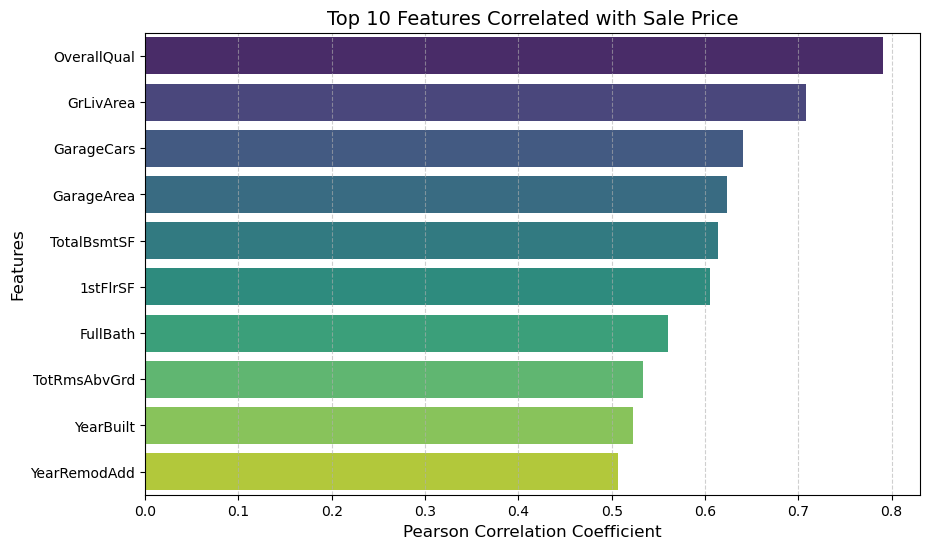

In [92]:
numeric_cols = df_housing.select_dtypes(include=['number'])

top_corr = numeric_cols.corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False).head(10)

corr_table = pd.DataFrame({'Correlation_with_SalePrice': top_corr})
print("Top 10 features most correlated with SalePrice (pre-outlier removal):\n")
display(corr_table)


plt.figure(figsize=(10, 6))
sns.barplot(x=top_corr.values, y=top_corr.index, palette='viridis', hue=top_corr.index, legend=False)

plt.title('Top 10 Features Correlated with Sale Price', fontsize=14)
plt.xlabel('Pearson Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(True, axis='x', linestyle='--', alpha=0.6)

plt.show()

### Step 4b: Multivariate Outlier Detection
Relying on a single feature to identify outliers can be misleading. A more robust approach is to combine our top two correlated features (`OverallQual` and `GrLivArea`) against `SalePrice`. 

By mapping `GrLivArea` to the X-axis, `SalePrice` to the Y-axis, and using `OverallQual` as the color hue, we can spot true anomalies: e.g., massive, high-quality homes sold for incredibly low prices.

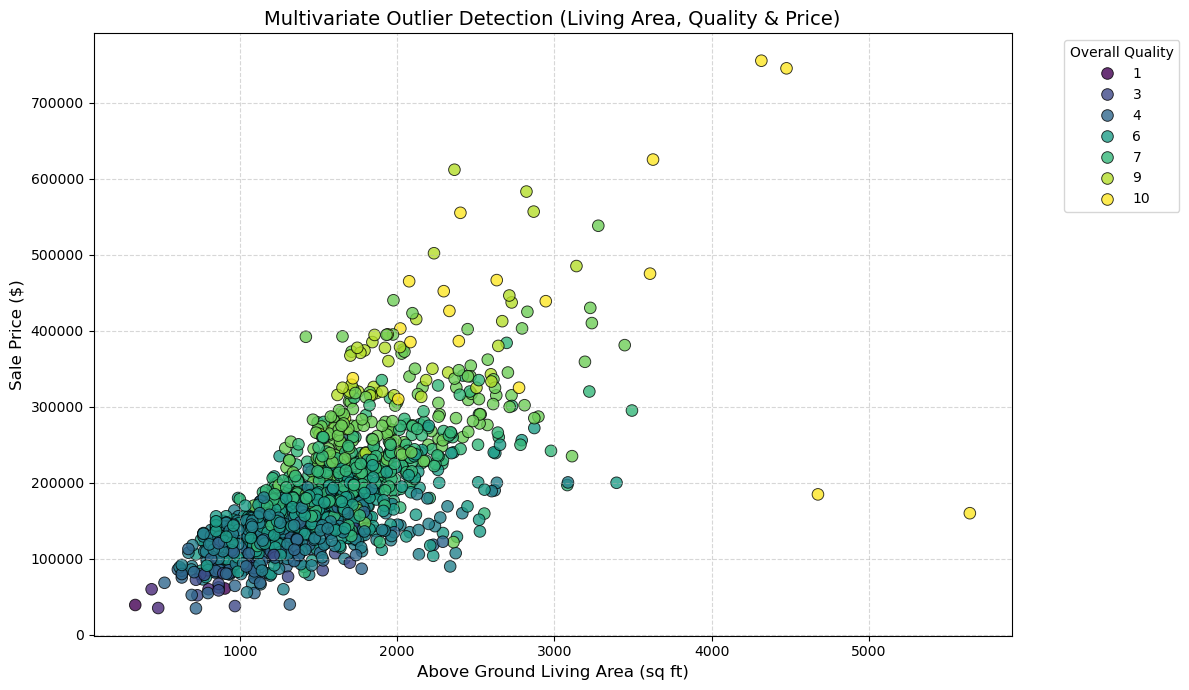

In [93]:
plt.figure(figsize=(12, 7))

sns.scatterplot(x=df_housing['GrLivArea'], 
                y=df_housing['SalePrice'], 
                hue=df_housing['OverallQual'], 
                palette='viridis', 
                edgecolor='k',
                s=70, 
                alpha=0.8)

plt.title('Multivariate Outlier Detection (Living Area, Quality & Price)', fontsize=14)
plt.xlabel('Above Ground Living Area (sq ft)', fontsize=12)
plt.ylabel('Sale Price ($)', fontsize=12)


plt.legend(title='Overall Quality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Step 4c: Removing Extreme Outliers
Based on our multivariate analysis, we identified two extreme outliers: houses with massive living areas (>4000 sq ft) and top-tier overall quality, yet sold for unusually low prices (<$200,000). 

Keeping these anomalies would severely skew our machine learning model's predictions. We will explicitly filter them out of our dataset.

In [94]:
outliers_index = df_housing[(df_housing['GrLivArea'] > 4000) & (df_housing['SalePrice'] < 200000)].index

df_housing = df_housing.drop(outliers_index)

df_housing = df_housing.reset_index(drop=True)

print(f"Successfully dropped {len(outliers_index)} extreme outliers.")
print(f"New dataset shape (rows, columns): {df_housing.shape}")

Successfully dropped 2 extreme outliers.
New dataset shape (rows, columns): (1458, 81)


### Step 5: Target Variable Analysis (SalePrice)
Before training any models, we need to examine the distribution of our target variable: `SalePrice`. Machine learning algorithms perform best when the target variable is normally distributed. 

Housing prices typically suffer from "right skewness" (a long tail on the right side) because there is a hard lower limit ($0) but no upper limit, meaning a few ultra-expensive mansions stretch the distribution. We will visualize this using a histogram and a Kernel Density Estimate (KDE).

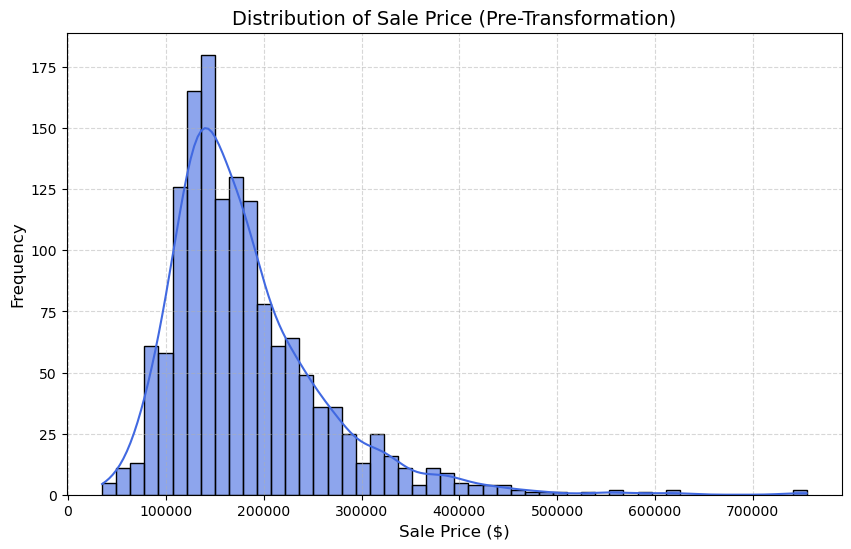

In [95]:
plt.figure(figsize=(10, 6))

sns.histplot(df_housing['SalePrice'], kde=True, bins=50, color='royalblue', alpha=0.6)

plt.title('Distribution of Sale Price (Pre-Transformation)', fontsize=14)
plt.xlabel('Sale Price ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

### Step 5a: Log-Transformation of the Target Variable
As seen in the previous histogram, `SalePrice` is right-skewed. To correct this and force the data into a normal distribution (which linear models favor), we apply a logarithmic transformation. 

**Why use `log1p` instead of standard `log`?**
*   We use `numpy.log1p()`, which mathematically calculates `log(1+x)`. 
*   Standard `log(0)` is undefined (results in negative infinity) and would break the code. By adding 1, a zero value safely becomes `log(1)`, which equals `0`.
*   Although a house price is never 0, using `log1p` is a standard defensive programming practice in Data Science. It builds a safe habit for transforming other variables (like basement area or pool size) that frequently contain zeros.

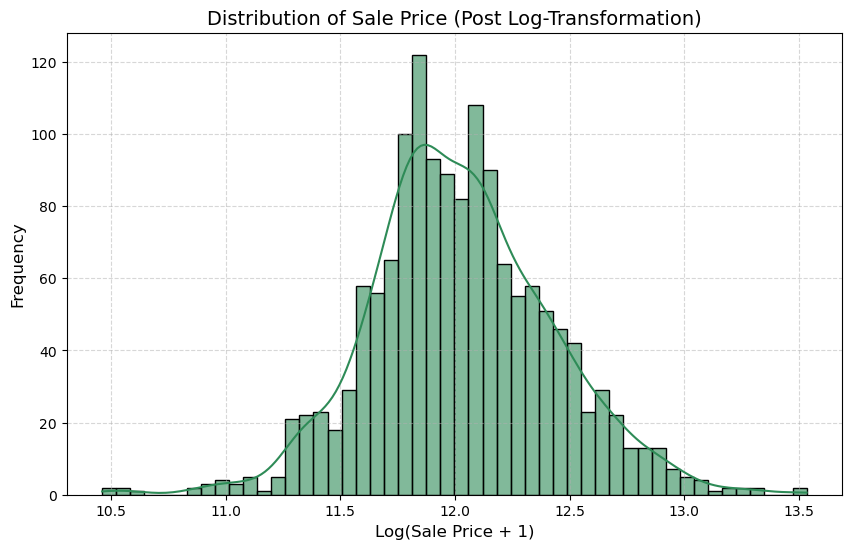

In [96]:
import numpy as np

df_housing['SalePrice'] = np.log1p(df_housing['SalePrice'])

plt.figure(figsize=(10, 6))
sns.histplot(df_housing['SalePrice'], kde=True, bins=50, color='seagreen', alpha=0.6)

plt.title('Distribution of Sale Price (Post Log-Transformation)', fontsize=14)
plt.xlabel('Log(Sale Price + 1)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

### Step 6: Feature Engineering - One-Hot Encoding
Machine learning algorithms cannot process raw text. We must translate all categorical variables (strings) into numerical formats. 

We will use **One-Hot Encoding** (`pd.get_dummies`) to convert categorical columns into a binary matrix (0s and 1s). 

**Important Note on `drop_first=True`:** 
We apply this parameter for two crucial reasons:
1. **Mathematical Stability:** It prevents the **Dummy Variable Trap** (perfect multicollinearity). If a feature has 3 categories (A, B, C), 2 columns are enough. If A=0 and B=0, the math naturally implies C=1.
2. **Computational Efficiency:** By dropping one column per category, we reduce the overall dimensionality of our dataset. This saves memory and decreases the computational load, allowing our machine learning models to train faster and more efficiently.

In [97]:
df_housing = pd.get_dummies(df_housing, drop_first=True)
display(df_housing.head())

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,False,False,False,True,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,False,False,False,True,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,False,False,False,True,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,False,False,False,False,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,False,False,False,False,True,False,False,False,True,False


### Step 7: Train-Test Split (Evaluation Framework)
To accurately evaluate our model's performance locally, we must split our current dataset into a training set and a validation (test) set. 

This step creates our final "exam." We lock 20% of the data away so the model never sees it during the learning phase. This allows us to test how well our algorithm generalizes to completely new, unseen houses before making any final predictions.

In [98]:
X = df_housing.drop('SalePrice', axis=1)
y = df_housing['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Step 8: Machine Learning Pipeline & Hyperparameter Tuning
Instead of manually scaling our data before modeling, we will construct a Scikit-Learn `Pipeline` combined with `GridSearchCV`.

**Why this approach?**
*   **Leakage Prevention in CV:** During Cross-Validation, data is split into multiple folds. If we scale the entire dataset beforehand, statistical information leaks across folds. A Pipeline ensures scaling is calculated strictly on the training portion of each CV iteration.

**Model Selection: Why ElasticNet (L1 + L2 Regularization)?**

Standard Linear Regression (Ordinary Least Squares) is far too fragile for our current dataset. Instead of blindly guessing whether Ridge or Lasso is better, we use **ElasticNet**, which mathematically combines both approaches:

*   **Feature Selection via L1 Penalty (Lasso):** Our One-Hot Encoding process expanded the dataset to over 200 binary columns. Many of these might be noise or rare categories (e.g., very specific roof materials). The L1 penalty acts as a built-in feature selector, forcing the coefficients of completely irrelevant features to exactly zero, effectively removing them and simplifying the model.
*   **Stability & Multicollinearity via L2 Penalty (Ridge):** Some features in the real estate market naturally overlap (e.g., *GarageCars* and *GarageArea*). Pure Lasso might arbitrarily drop one of them, losing valuable context. The L2 penalty prevents this by shrinking extreme coefficients smoothly and handling correlated features with mathematical stability.
*   **Letting the Data Decide:** By tuning the `l1_ratio` hyperparameter inside our `GridSearchCV`, we are not making arbitrary assumptions. We allow the algorithm to empirically find the absolute best "sweet spot" between aggressive feature elimination (Lasso) and conservative weight shrinkage (Ridge).
 
 
**Technical Note on `l1_ratio=0.002`:** You might wonder why we use `0.002` instead of `0.0` to simulate pure Ridge regression. Scikit-Learn's `ElasticNet` uses a *Coordinate Descent* solver that becomes numerically unstable and fails to converge when the L1 penalty is exactly zero. Adding a microscopic fraction of L1 (`0.002`) keeps the algorithm fast and stable while mathematically behaving identical to a pure Ridge (L2) model.

**A Note on Missing Value Imputation:**
In production pipelines, it is highly recommended to include a `SimpleImputer` as the first step to automatically handle missing data and prevent application crashes. However, we intentionally omitted it here and handled missing values manually in Step 3. In the Ames dataset, `NaN` often carries strict business meaning (e.g., `NaN` in `PoolQC` means "No Pool", not a missing record). Using a naive automated imputer (like median or most frequent) would mathematically assign pools or garages to houses that physically do not have them.

In [99]:
pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', ElasticNet(max_iter=10000, random_state=42))
])


param_grid = {
    'model__alpha': [0.1, 1.0, 10.0, 50.0, 100.0, 200.0],
    'model__l1_ratio': [0.002, 0.5, 0.9, 1.0] 
}


grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    verbose=1,
    n_jobs=-1
)

print("Pipeline and GridSearchCV successfully configured!")

Pipeline and GridSearchCV successfully configured!


### Step 9: Model Training and Cross-Validation Results

With our Pipeline and GridSearch configured, it is time to execute the training process. 

By calling `.fit(X_train, y_train)`, the algorithm will run 5-fold Cross-Validation for every combination of `alpha` and `l1_ratio` we provided. It will scale the data dynamically within each fold to prevent leakage and ultimately select the model that achieves the best overall performance.

**Why optimize for the $R^2$ (R-squared) metric?**
While metrics like MAE (Mean Absolute Error) or RMSE (Root Mean Squared Error) calculate the error in actual dollars, we chose $R^2$ as our primary GridSearch scoring metric for three strategic reasons:

1. **Business Interpretability:** $R^2$ represents the proportion of variance in the target variable (SalePrice) that is explained by our model. An $R^2$ of 0.9 means our features explain 90% of why house prices differ from one another. This percentage-like interpretation is highly intuitive for business stakeholders to grasp.
2. **Scale Independence:** House prices in our dataset vary wildly (from $30,000 to over $700,000). Absolute error metrics like RMSE heavily penalize large errors, which might force the model to over-optimize for predicting ultra-expensive mansions just to reduce the dollar-value penalty. $R^2$ provides a normalized, unitless measure of the "goodness of fit" across the entire price spectrum.
3. **Built-in Baseline Proof:** $R^2$ mathematically compares our model's predictions against a "dummy" baseline (a naive model that just predicts the average house price every single time). Optimizing for $R^2$ ensures we are maximizing how much *actual intelligence* our algorithm adds beyond a simple average guess.

In [100]:
print("Starting model training and hyperparameter tuning...")
start_time = time.time()


grid_search.fit(X_train, y_train)

end_time = time.time()
print(f"Training completed in {end_time - start_time:.2f} seconds.\n")

best_alpha = grid_search.best_params_['model__alpha']
best_l1_ratio = grid_search.best_params_['model__l1_ratio']
best_cv_r2 = grid_search.best_score_

print(f" Best Hyperparameters:")
print(f"   - alpha: {best_alpha}")
print(f"   - l1_ratio: {best_l1_ratio}")
print(f" Best R-squared score during Cross-Validation: {best_cv_r2:.4f}")

Starting model training and hyperparameter tuning...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Training completed in 6.04 seconds.

 Best Hyperparameters:
   - alpha: 0.1
   - l1_ratio: 0.002
 Best R-squared score during Cross-Validation: 0.9053


### Step 10: Final Model Evaluation and Business Metrics

We have found our optimal model configuration. Now, we will predict house prices on our hold-out test set (`X_test`). 

R-squared is great for statistical validation, but we also need to understand our errors in real dollars. Because we log-transformed the target variable in Step 5a, we must inverse-transform our predictions and actual values using `np.expm1()` before calculating real-world error metrics.

**Understanding our Business Metrics:**
*   **MAE (Mean Absolute Error):** The most intuitive metric for business stakeholders. It simply answers the question: *"On average, by how many dollars is our model's prediction wrong?"* It treats all errors equally, whether the house is cheap or expensive.
*   **RMSE (Root Mean Squared Error):** Because its mathematical formula squares the errors before averaging them, RMSE acts as a strict penalty system for large mistakes. If our model is fairly accurate on normal houses but wildly wrong on a few million-dollar mansions, the RMSE will spike significantly higher than the MAE. 

By looking at both, we get a complete picture: MAE tells us our typical everyday error, while RMSE warns us if we have any extreme, unacceptable misses.

In [101]:
y_pred_log_elastic_net = grid_search.predict(X_test)


y_pred_dollars_elastic_net = np.expm1(y_pred_log)
y_test_dollars_elastic_net = np.expm1(y_test)


test_r2_elastic_net = r2_score(y_test, y_pred_log) 
test_mae_elastic_net = mean_absolute_error(y_test_dollars, y_pred_dollars)
test_rmse_elastic_net = np.sqrt(mean_squared_error(y_test_dollars, y_pred_dollars))

print("Final Evaluation on Unseen Test Data:\n")
print(f"Statistical R-squared:  {test_r2:.4f}")
print(f"Mean Absolute Error:    ${test_mae:,.2f})")
print(f"Root Mean Squared Err:  ${test_rmse:,.2f}")

Final Evaluation on Unseen Test Data:

Statistical R-squared:  0.8950
Mean Absolute Error:    $15,398.30)
Root Mean Squared Err:  $21,958.92


### Step 11: ElasticNet Summary & Transition to XGBoost

Our baseline **ElasticNet** model performed exceptionally well, achieving an R-squared of ~0.895 and a Mean Absolute Error of ~$15,398 on completely unseen data. This proves our data cleaning, feature engineering, and anti-leakage pipeline were highly effective.

However, linear models have a fundamental limitation: they assume a straight-line relationship between features and the target price. They often struggle to capture complex, non-linear interactions.

To see if we can push our accuracy even further, we will now train an **XGBoost (Extreme Gradient Boosting)** model. XGBoost is an advanced ensemble of decision trees that naturally handles non-linear relationships and outliers. 

**Why is XGBoost a perfect fit for our dataset?**
*   **Sequential Error Correction (Boosting):** Unlike linear models that calculate one global mathematical equation, XGBoost builds hundreds of trees sequentially. Each new tree is specifically trained to correct the residual errors made by the previous trees.
*   **Sparsity Awareness:** Our One-Hot Encoding created over 200 binary columns (a matrix heavily populated with 0s). XGBoost contains a specialized internal algorithm optimized exactly for this kind of sparse data, making it computationally fast and highly accurate without getting confused by the zeros.
*   **Built-in Regularization:** Just like our ElasticNet, XGBoost includes L1 and L2 mathematical penalties under the hood. This prevents the trees from growing too deep and memorizing the training data, combining the non-linear power of decision trees with strict statistical discipline.

**Technical Note:**
Because of Scikit-Learn's modular design, we do not need to write a new training architecture from scratch. We can elegantly recycle our existing `Pipeline` and `GridSearchCV` objects.
*(Note: While XGBoost does not mathematically require the `StandardScaler` still present in our pipeline, leaving it there does not negatively impact the tree-based model's performance and allows for seamless code reuse).*

In [102]:

pipeline.set_params(model=XGBRegressor(random_state=42))


grid_search.estimator = pipeline

xgb_param_grid = {
    'model__n_estimators': [100, 300, 500],
    'model__max_depth': [3, 4, 5],
    'model__learning_rate': [0.01, 0.05, 0.1]
}

grid_search.param_grid = xgb_param_grid

print("Existing Pipeline and GridSearchCV successfully updated with XGBoost!")

Existing Pipeline and GridSearchCV successfully updated with XGBoost!


In [103]:
print("Starting XGBoost training and hyperparameter tuning...")


start_time = time.time()


grid_search.fit(X_train, y_train)

end_time = time.time()
print(f"Training completed in {end_time - start_time:.2f} seconds.\n")

best_xgb_params = grid_search.best_params_
best_xgb_cv_r2 = grid_search.best_score_

print("Best Hyperparameters for XGBoost:")
for param, value in best_xgb_params.items():
    print(f"   - {param}: {value}")
    
print(f"\n Best R-squared score during Cross-Validation: {best_xgb_cv_r2:.4f}")

Starting XGBoost training and hyperparameter tuning...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Training completed in 29.20 seconds.

Best Hyperparameters for XGBoost:
   - model__learning_rate: 0.05
   - model__max_depth: 3
   - model__n_estimators: 500

 Best R-squared score during Cross-Validation: 0.9002


### Step 12: XGBoost Evaluation on Unseen Data

The moment of truth. Even though XGBoost scored slightly lower than Ridge Regression during Cross-Validation, we need to evaluate its real-world performance. 

We will use the same metric extraction method as in Step 10, reversing the log transformation with `np.expm1()`, to see if the decision trees can beat the baseline Mean Absolute Error of **$15,398**.

In [104]:
y_pred_log_xgb = grid_search.predict(X_test)


y_pred_dollars_xgb = np.expm1(y_pred_log_xgb)


test_r2_xgb = r2_score(y_test, y_pred_log_xgb) 
test_mae_xgb = mean_absolute_error(y_test_dollars, y_pred_dollars_xgb)
test_rmse_xgb = np.sqrt(mean_squared_error(y_test_dollars, y_pred_dollars_xgb))

print("Final XGBoost Evaluation on Unseen Test Data:\n")
print(f"Statistical R-squared:  {test_r2_xgb:.4f}")
print(f"Mean Absolute Error:    ${test_mae_xgb:,.2f}")
print(f"Root Mean Squared Err:  ${test_rmse_xgb:,.2f}")

Final XGBoost Evaluation on Unseen Test Data:

Statistical R-squared:  0.9092
Mean Absolute Error:    $14,987.02
Root Mean Squared Err:  $20,280.96


### Step 13: Final Model Analysis & Visual Comparison

Our comparison table below reveals a clear winner. While both algorithms performed exceptionally well, **XGBoost** outperformed ElasticNet across all metrics. 

**Key Analytical Insights:**
1. **Higher Baseline Precision (MAE):** XGBoost reduced the average prediction error by over $400 per house, bringing our Mean Absolute Error down to ~$14,987.
2. **Superior Outlier Handling (RMSE):** The most significant improvement is seen in the RMSE metric, which dropped by roughly $1,700. This proves our hypothesis from Step 11: XGBoost's non-linear, tree-based logic is vastly superior at evaluating extreme cases (like unique, ultra-expensive mansions), whereas the linear ElasticNet struggled with those non-standard properties.
3. **Variance Explained ($R^2$):** Breaking the 0.90 barrier means our model now confidently explains ~91% of all price fluctuations in the Ames housing market.

To visually demonstrate this victory, we will plot the predictions of **both models on a single chart**. The red dashed line represents perfect accuracy ($Y = X$). Notice how the XGBoost predictions tend to cluster tighter around the red line, especially in the higher price brackets ($300k+), successfully correcting the mistakes made by ElasticNet.

Model Comparison Table:


,R-squared,MAE ($),RMSE ($)
Elastic Net,0.895038,15398.297720,21958.920245
XGBoost,0.909185,14987.021391,20280.961644


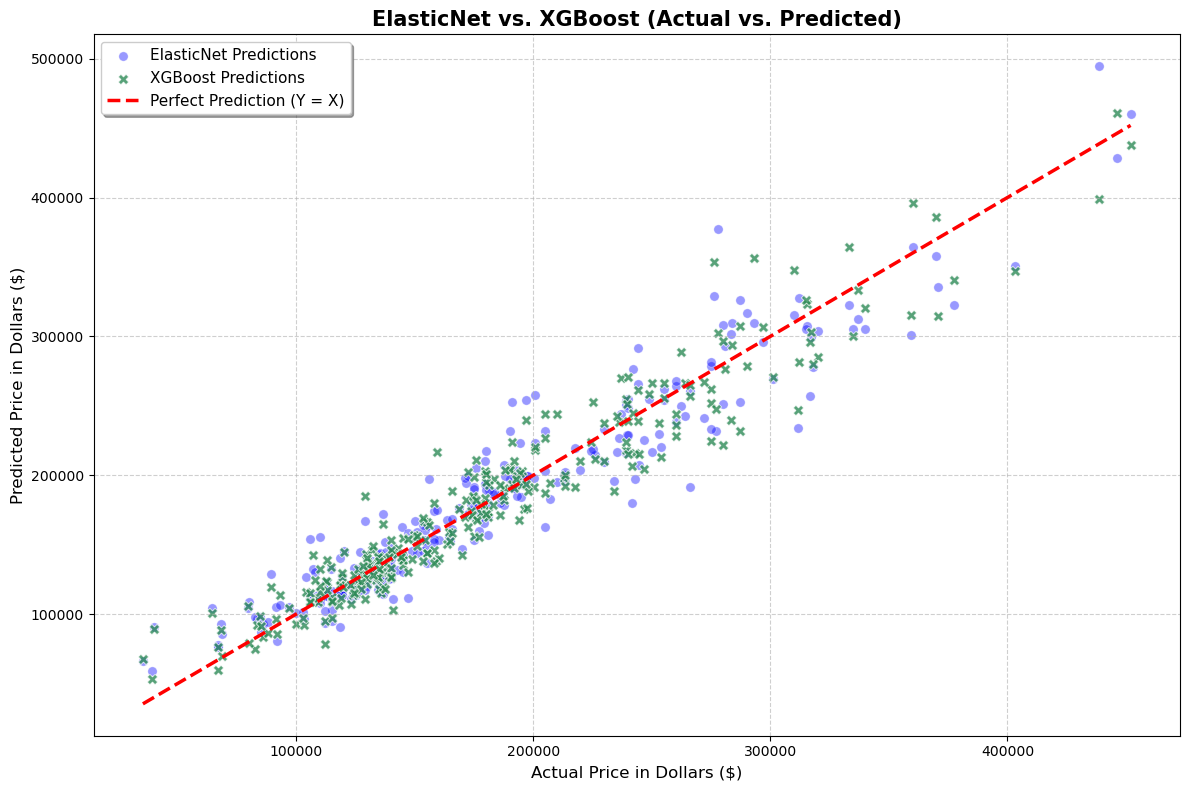

In [105]:
results_df = pd.DataFrame({
    'Model': ['Elastic Net', 'XGBoost'],
    'R-squared': [test_r2_elastic_net, test_r2_xgb],
    'MAE ($)': [test_mae_elastic_net, test_mae_xgb],
    'RMSE ($)': [test_rmse_elastic_net, test_rmse_xgb]
}).set_index('Model').rename_axis(None)

print("Model Comparison Table:")
display(results_df)


plt.figure(figsize=(12, 8))


sns.scatterplot(x=y_test_dollars, y=y_pred_dollars_elastic_net, 
                alpha=0.4, color='blue', label='ElasticNet Predictions', s=45, marker='o')

sns.scatterplot(x=y_test_dollars, y=y_pred_dollars_xgb, 
                alpha=0.8, color='seagreen', label='XGBoost Predictions', s=55, marker='X')


min_val = min(y_test_dollars)
max_val = max(y_test_dollars)

plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2.5, label='Perfect Prediction (Y = X)')

plt.title('ElasticNet vs. XGBoost (Actual vs. Predicted)', fontsize=15, fontweight='bold')
plt.xlabel('Actual Price in Dollars ($)', fontsize=12)
plt.ylabel('Predicted Price in Dollars ($)', fontsize=12)
plt.legend(loc='upper left', fontsize=11, frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Step 14: Business Insights & Feature Importance (What actually drives the price?)

Predicting the exact price of a house is only half the battle. From a business perspective (e.g., for real estate investors or home flippers), understanding *why* a house is priced a certain way is equally valuable. 

Tree-based models like **XGBoost** provide a built-in metric called **Feature Importance**. By analyzing thousands of decision trees, the algorithm calculates how much each specific feature (like square footage, neighborhood, or overall quality) contributed to reducing the prediction error.

Below, we extract the top 10 most influential factors from our winning XGBoost model. This visual report acts as a practical guide on what buyers and sellers should pay the most attention to when evaluating a property.

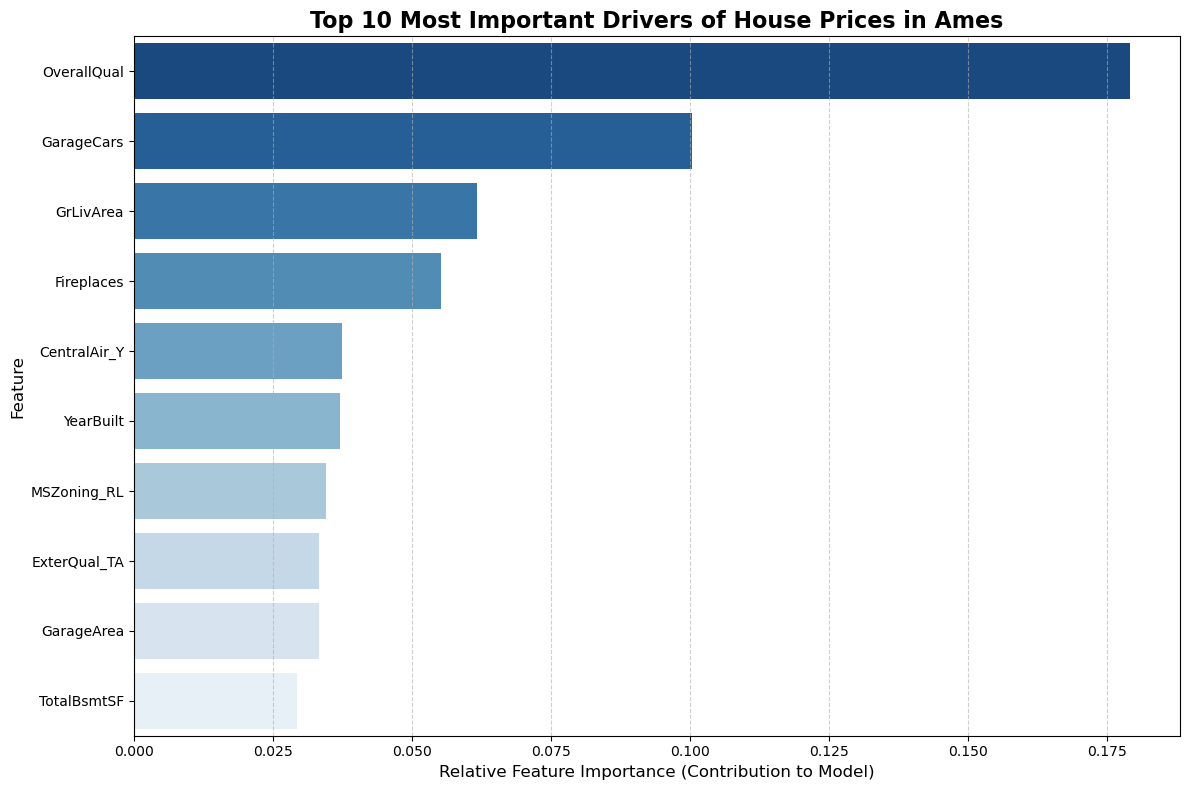

In [106]:

best_xgb_model = grid_search.best_estimator_.named_steps['model']

importances = best_xgb_model.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


plt.figure(figsize=(12, 8))

sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), hue='Feature', palette='Blues_r', legend=False)


plt.title('Top 10 Most Important Drivers of House Prices in Ames', fontsize=16, fontweight='bold')
plt.xlabel('Relative Feature Importance (Contribution to Model)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Conclusion & Business Glossary

Our analysis concludes that while machine learning algorithms can process hundreds of distinct property features, the Ames housing market is primarily driven by a narrow core of key variables. This mathematically confirms for investors and homeowners that focusing on foundational quality and essential amenities yields the highest return on investment.

**Top 3 Price Drivers (Based on our XGBoost model):**
*   **OverallQual (Overall Material and Finish Quality):** The absolute most important factor, which heavily dominates our chart. It evaluates the general construction and finish quality of the house on a scale from 1 (Very Poor) to 10 (Very Excellent).
*   **GarageCars (Garage Capacity):** A highly significant attribute measuring the garage size by car capacity. From a logical standpoint, this acts as a strong proxy for wealth—buyers of high-end, premium properties generally own multiple vehicles. Therefore, a large garage is a powerful indicator of a luxury home.
*   **GrLivArea (Above Ground Living Area):** The total square footage of the living space situated strictly above ground level (this explicitly excludes basement areas).